# Seasonal Clustering - K-Means Analysis

**Dataset:** `data/clean/final_dataset_full_clean.csv`  
Goal: Identify meteorological clusters and statistically validate their alignment with calendar seasons, while investigating price volatility within those regimes.

Features used (seasonal angle only):
- `temperature_2m` - drives heating/cooling demand
- `shortwave_radiation` - proxy for solar generation potential
- `cloud_cover` - affects solar output and demand
- `wind_speed_10m` - proxy for wind generation potential

## 1. Load Data

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import chi2_contingency

df = pd.read_csv('../data/clean/final_dataset_full_clean.csv', parse_dates=['time'])

print(f"Loaded {len(df):,} rows spanning {df['time'].min().date()} → {df['time'].max().date()}")

Loaded 96,133 rows spanning 2015-01-04 → 2025-12-31


---

## 2. Define Calendar Seasons

Map each row to a meteorological season (Winter, Spring, Summer, Autumn) based on the month column.

In [21]:
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    if month in [3, 4, 5]: return 'Spring'
    if month in [6, 7, 8]: return 'Summer'
    return 'Autumn'

df['actual_season'] = df['month'].apply(get_season)

print("Season distribution:")
print(df['actual_season'].value_counts().to_string())

Season distribution:
actual_season
Summer    24288
Spring    24180
Autumn    24000
Winter    23665


---

## 3. Weather-Only Clustering

Cluster days using only meteorological features - the model never sees price. This ensures any price patterns we find later are genuinely driven by weather, not circular.

In [22]:
weather_features = ['temperature_2m', 'shortwave_radiation', 'wind_speed_10m', 'cloud_cover']
X = df[weather_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['weather_cluster'] = kmeans.fit_predict(X_scaled)

counts = df['weather_cluster'].value_counts().sort_index()
print("Days assigned per weather cluster:")
for cluster, n in counts.items():
    print(f"  Cluster {cluster}: {n:,} rows ({n / len(df) * 100:.1f}%)")

Days assigned per weather cluster:
  Cluster 0: 18,085 rows (18.8%)
  Cluster 1: 35,187 rows (36.6%)
  Cluster 2: 23,164 rows (24.1%)
  Cluster 3: 19,697 rows (20.5%)


**Expected output:** Four clusters each covering a rough share of the dataset. Uneven splits are normal - some weather regimes are more common than others.

---

## 4. Statistical Significance Test

Use a **Chi-Square test** to check whether the weather clusters are statistically independent from calendar seasons. **Cramér's V** then measures the strength of that association (0 = none, 1 = perfect).

In [23]:
contingency_table = pd.crosstab(df['actual_season'], df['weather_cluster'])

chi2, p, dof, ex = chi2_contingency(contingency_table)

n = contingency_table.sum().sum()
v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

print(f"Chi-Square statistic : {chi2:.2f}  (dof={dof})")
print(f"p-value              : {p:.4e}  {'significant' if p < 0.001 else 'not significant'}")
print(f"Cramér's V           : {v:.3f}  ({'strong' if v > 0.3 else 'moderate' if v > 0.15 else 'weak'} association)")

Chi-Square statistic : 17868.29  (dof=9)
p-value              : 0.0000e+00  ✓ significant
Cramér's V           : 0.249  (moderate association)


---

## 5. Side-by-Side: Cluster Colours vs. Season Colours

The same data points plotted twice in the same 2D space (temperature × radiation). On the left each point is coloured by the K-means cluster it was assigned to; on the right the same points are coloured by the actual calendar season. Visual overlap between the two panels shows how well the clusters recovered seasonal structure without ever seeing season labels.

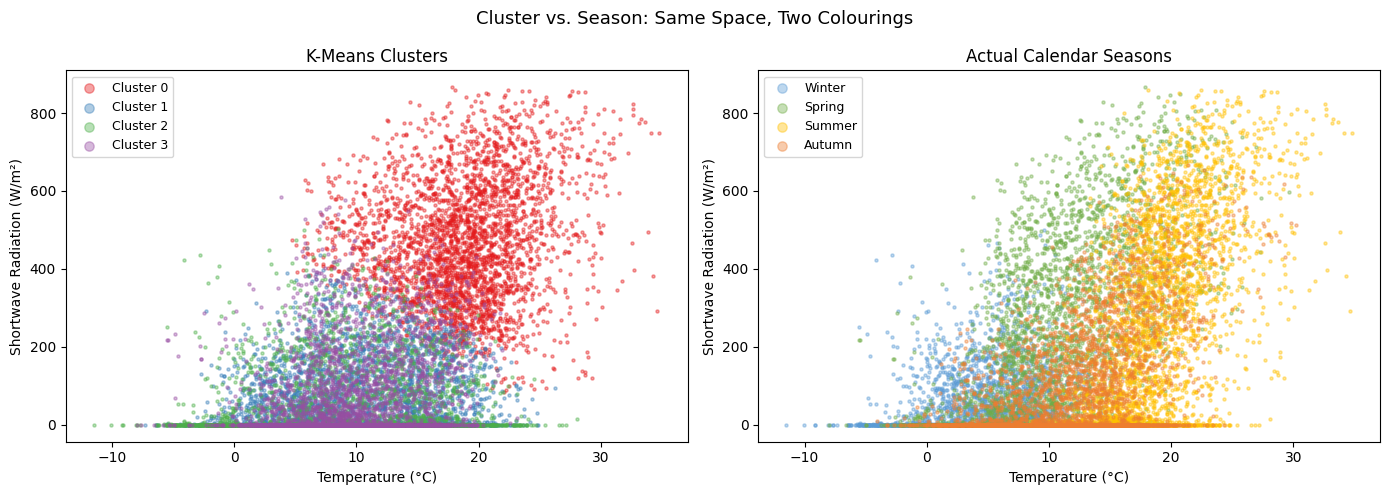

In [24]:
CLUSTER_COLORS  = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']   # distinct, not seasonal
SEASON_COLORS   = {'Winter': '#5b9bd5', 'Spring': '#70ad47',
                   'Summer': '#ffc000', 'Autumn': '#ed7d31'}
SEASON_ORDER    = ['Winter', 'Spring', 'Summer', 'Autumn']

# Subsample for readability
plot_df = df.iloc[::6][['temperature_2m', 'shortwave_radiation',
                         'wind_speed_10m', 'weather_cluster', 'actual_season']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: coloured by K-means cluster
for c in sorted(plot_df['weather_cluster'].unique()):
    m = plot_df['weather_cluster'] == c
    axes[0].scatter(plot_df.loc[m, 'temperature_2m'],
                    plot_df.loc[m, 'shortwave_radiation'],
                    s=5, alpha=0.4, color=CLUSTER_COLORS[c], label=f'Cluster {c}')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Shortwave Radiation (W/m²)')
axes[0].set_title('K-Means Clusters')
axes[0].legend(markerscale=3, fontsize=9)

# RIGHT: coloured by actual calendar season
for season in SEASON_ORDER:
    m = plot_df['actual_season'] == season
    axes[1].scatter(plot_df.loc[m, 'temperature_2m'],
                    plot_df.loc[m, 'shortwave_radiation'],
                    s=5, alpha=0.4, color=SEASON_COLORS[season], label=season)
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Shortwave Radiation (W/m²)')
axes[1].set_title('Actual Calendar Seasons')
axes[1].legend(markerscale=3, fontsize=9)

fig.suptitle('Cluster vs. Season: Same Space, Two Colourings', fontsize=13)
plt.tight_layout()
plt.show()

---

## 5. Visualize Cluster-Season Overlap

Two side-by-side charts:
- **Left:** Heatmap showing what fraction of each calendar season falls in each weather cluster - reveals how "seasonal" the clusters truly are.
- **Right:** Price volatility (std dev) per cluster - shows which weather regime causes the most price uncertainty.

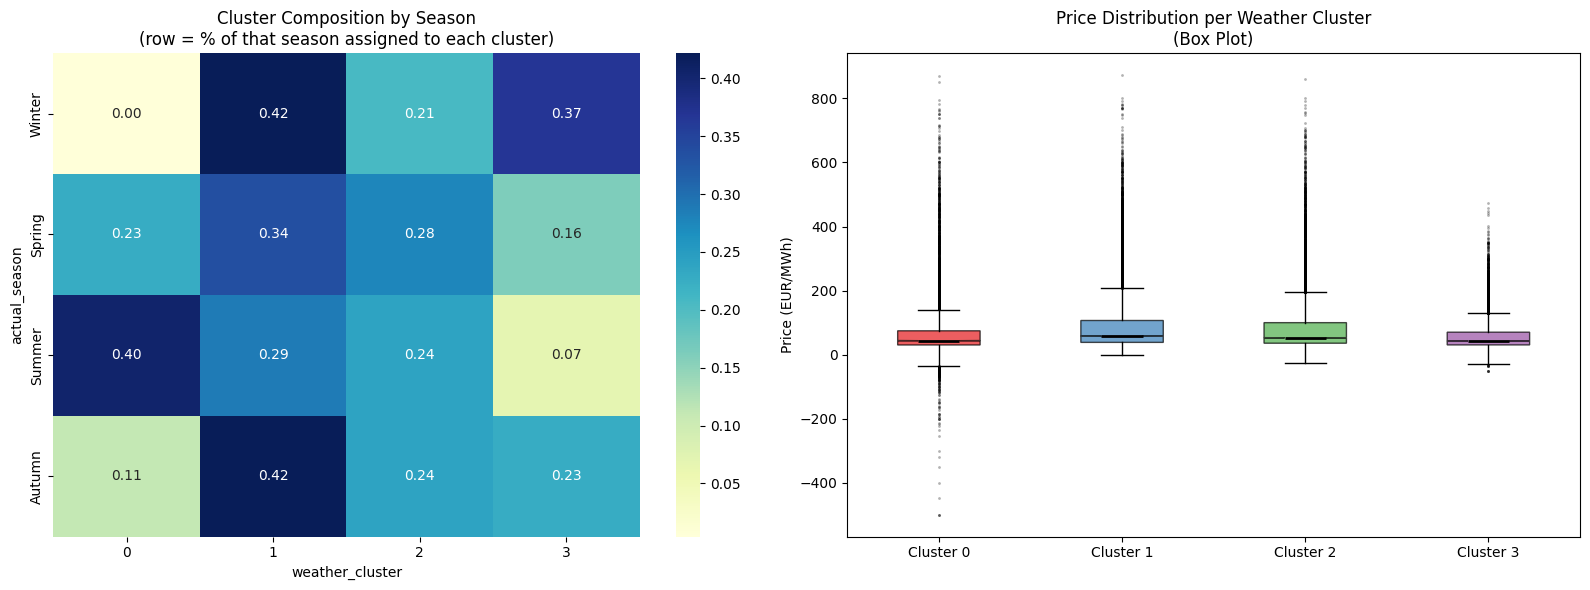

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: fraction of each calendar season that falls in each cluster
sns.heatmap(
    pd.crosstab(df['actual_season'], df['weather_cluster'], normalize='index').loc[SEASON_ORDER],
    annot=True, fmt='.2f', cmap='YlGnBu', ax=ax1,
)
ax1.set_title('Cluster Composition by Season\n(row = % of that season assigned to each cluster)')

# Right: box plot of price per cluster — shows spread and outliers, not just mean ± std
price_groups = [df.loc[df['weather_cluster'] == c, 'price'].values for c in range(4)]
bp = ax2.boxplot(
    price_groups,
    patch_artist=True,
    notch=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='.', markersize=2, alpha=0.3),
)
for patch, color in zip(bp['boxes'], CLUSTER_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_xticklabels([f'Cluster {c}' for c in range(4)])
ax2.set_ylabel('Price (EUR/MWh)')
ax2.set_title('Price Distribution per Weather Cluster\n(Box Plot)')

plt.tight_layout()
plt.show()

## Interpretation

**Statistical association (Cramér's V ~= 0.249)**
The chi-square test confirms that cluster membership and calendar season are not independent (p < 0.001). The Cramér's V of around 0.25 indicates a weak-to-moderate association - real, but not perfect.

**Winter and Summer are clearly separated**
The scatter and heatmap both show that winter and summer occupy very different corners of the feature space. These two clusters have high within-season purity - one cluster is predominantly winter, another predominantly summer.

**Spring and Autumn explain the imperfect association**
The "noise" in Cramér's V comes from spring and autumn. A warm October day and a cool May day are meteorologically indistinguishable - same radiation angle, similar temperatures. The algorithm has no way of knowing which month it is, so these transitional seasons share cluster membership. Their low dominance values in the heatmap are not a failure of the clustering; they reflect genuine seasonal ambiguity in the data.

**Why does one cluster have a much wider price spread?**
The cluster that spans the most across seasons (the autumn/spring mix) also tends to show the widest price box plot. This makes sense: both warm spring days and cold autumn days under different supply conditions, price dispersion increases. The box plot makes this visible in a way the mean +/- std bar chart could not - the range and tail length tell the full story.